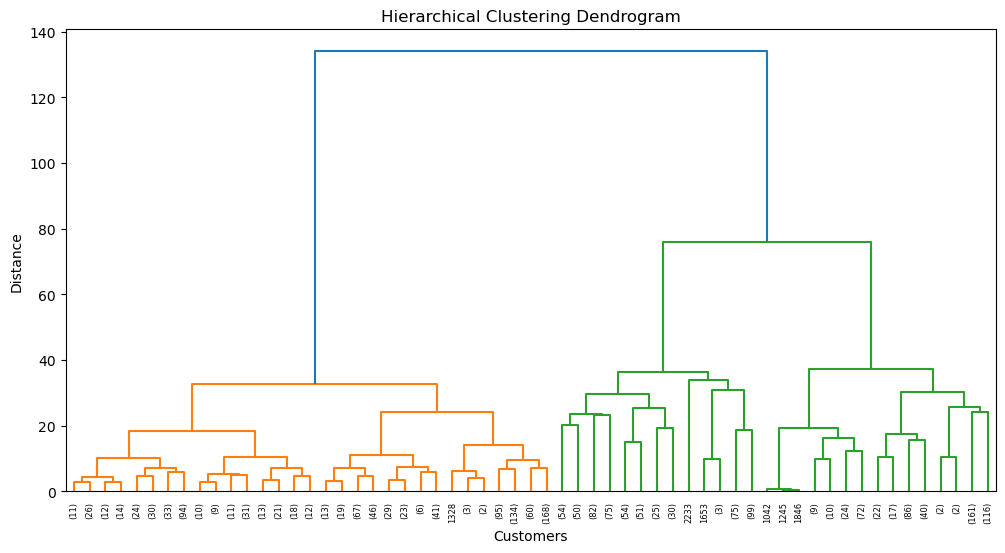

               Income    MntWines  MntFruits  MntMeatProducts  \
Cluster                                                         
1        35410.824349   52.363383   4.840149        24.881041   
2        73386.117577  533.888361  84.510689       411.439430   
3        82046.622905  770.860335  35.642458       531.849162   
4        53064.419492  460.305085  15.220339       137.406780   
5        60689.496637  465.035874  22.318386       140.280269   

         MntFishProducts  MntSweetProducts  MntGoldProds  NumDealsPurchases  \
Cluster                                                                       
1               6.862454          4.792751     15.613383           2.142193   
2             109.608076         84.263658     93.121140           1.627078   
3              67.620112         41.575419     50.284916           1.357542   
4              25.618644         22.847458     53.110169           7.245763   
5              34.531390         22.087444     61.293722           2.5

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Step 1: Load dataset
df = pd.read_csv("new.csv")

# Step 2: Handle missing values (Income column has blanks)
df['Income'] = df['Income'].fillna(df['Income'].median())

# Step 3: Select numeric features for clustering
numeric_cols = ['Income','MntWines','MntFruits','MntMeatProducts',
                'MntFishProducts','MntSweetProducts','MntGoldProds',
                'NumDealsPurchases','NumWebPurchases','NumCatalogPurchases',
                'NumStorePurchases','NumWebVisitsMonth']

X = df[numeric_cols]

# Step 4: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Perform hierarchical clustering
linked = linkage(X_scaled, method='ward')

# Step 6: Plot dendrogram
plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

# Step 7: Cut dendrogram into clusters (example: 5 clusters)
clusters = fcluster(linked, 5, criterion='maxclust')
df['Cluster'] = clusters

# Step 8: Analyze clusters
cluster_summary = df.groupby('Cluster')[numeric_cols].mean()
print(cluster_summary)
